# Image Processing 

### You are a computer vision engineer at FreshTrack, a produce supply chain company. Warehouses receive mixed crates of fruit and need to automatically sort them by type, flag color defects (underripe or overripe), and count individual pieces before packing. Manualinspection is slow and inconsistent under variable warehouse lighting Your job is to build a CV pipeline using OpenCV that can: (1) identify fruit types by color, (2) clean up noisy camera images, (3) detect fruit shape features, and (4) count individual round fruits in a batch image.

In [2]:
import cv2 as cv
import matplotlib.pyplot as plt 
import numpy as np 

# Part A — Color Space & Fruit Segmentation


### 1. Load red_apple.jpg in BGR using cv2.imread(). Display it correctly in Matplotlib (convert to RGB first). Then display the raw BGR version. What do you notice about the colors?

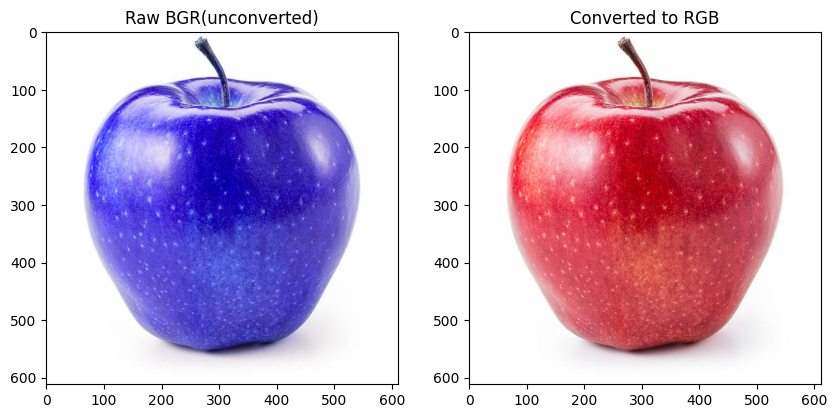

In [16]:
img_bgr = cv.imread("Images/red_apple.png")
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)



fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(img_bgr)
axes[0].set_title('Raw BGR(unconverted)')
axes[1].imshow(img_rgb)
axes[1].set_title('Converted to RGB')
plt.show()



> Note

A digital color img is a 3D grid of number height x widht x 2(BGR).
Open CV stores them as BGR not RGB

plt, PIL, and everyother thing expects RBG format

In [18]:
# observations 
# the apple is blue in left side and red in right side the 
# the correct order of the image was RGB; the left one switched 
# the value of R(Red) with the blue 
# left image - 0000FF
# right image - FF0000


### 2. Convert red_apple.jpg to HSV. Visualize the H,S, and V channels side by side as grayscale images. Which channel best separates the fruit from its white background?

Text(0.5, 1.0, 'HSV')

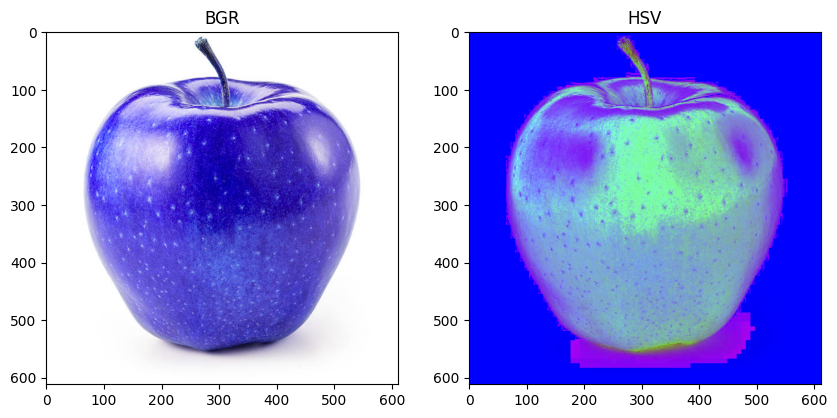

In [42]:
img_bgr = cv.imread("Images/red_apple.png")
img_hsv = cv.cvtColor(img_rgb, cv.COLOR_BGR2HSV)

fig, axes = plt.subplots(1,2, figsize = (10,5))
axes[0].imshow(img_bgr)
axes[0].set_title("BGR")
axes[1].imshow(img_hsv)
axes[1].set_title('HSV')


# HSV = HUe, Saturation, Value

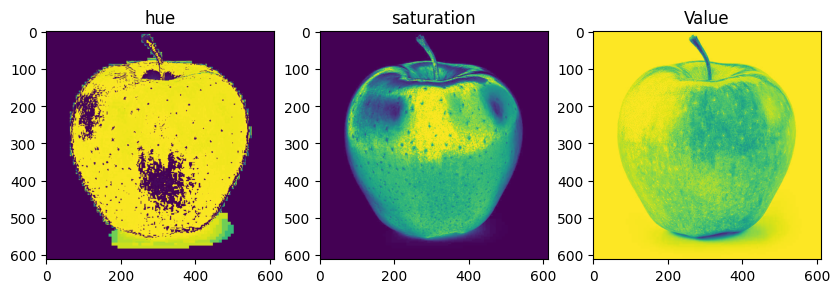

In [51]:
img_hsv = cv.cvtColor(img_rgb, cv.COLOR_RGB2HSV)

h, s, v = cv.split(img_hsv)

fig, axes = plt.subplots(1,3, figsize = (10,5))
axes[0].imshow(h)
axes[0].set_title("hue")
axes[1].imshow(s)
axes[1].set_title("saturation")
axes[2].imshow(v)
axes[2].set_title("Value")
plt.show()


The saturation (S) channel seprates the fruit from its white background. Whie is defined as a color with essentially zero saturation, regardless of how bright it is, white carries no "colourfullness

### 3. Masking by color: use cv2.inRange() in HSV to isolate the red apple. Red wraps around the Hue axis (0–10 and 170–180). Create two masks and combine with cv2.bitwise_or(). Display: original | mask | masked result.

Text(0.5, 1.0, 'mask result ')

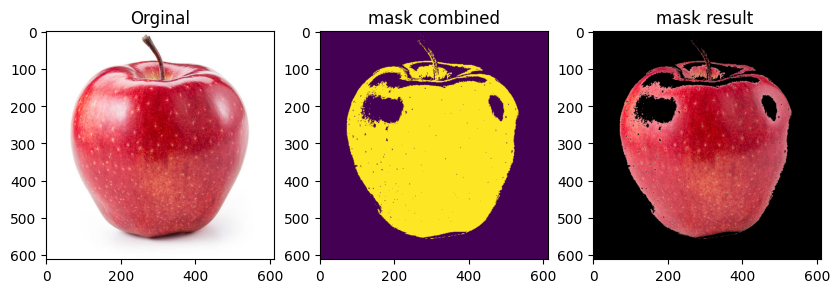

In [58]:
lower_red1 = np.array([0, 100, 100])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([170, 100, 100])
upper_red2 = np.array([179, 255,255])
mask1 = cv.inRange(img_hsv, lower_red1, upper_red1)
mask2 = cv.inRange(img_hsv, lower_red2, upper_red2)
mask_combined = cv.bitwise_or(mask1, mask2)
mask_result = cv.bitwise_and(img_rgb, img_rgb, mask=mask_combined)

fig, axes = plt.subplots(1,3, figsize= (10,5))
axes[0].imshow(img_rgb)
axes[0].set_title('Orginal')
axes[1].imshow(mask_combined)
axes[1].set_title('mask combined')
axes[2].imshow(mask_result)
axes[2].set_title('mask result ')



### 4.Color table task: repeat the HSV masking for green_apple.jpg, banana.jpg, and lime.jpg. Record each fruit’s working HSV range as a markdown table: Fruit | H_min | H_max | S_min | S_max | V_min |  V_max.

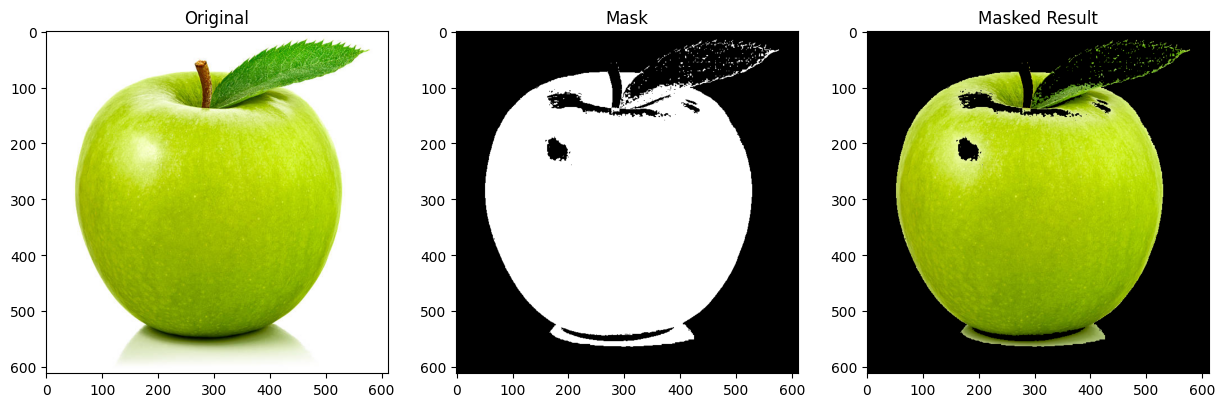

In [88]:
img_green = cv.imread('Images/green_apple.png')
img_green_hsv = cv.cvtColor(img_green, cv.COLOR_BGR2HSV)
img_green_rgb = cv.cvtColor(img_green, cv.COLOR_BGR2RGB)

lower_green = np.array([25, 90, 80])
upper_green = np.array([45, 255, 255])

mask_green = cv.inRange(img_green_hsv, lower_green, upper_green)
result_green = cv.bitwise_and(img_green_rgb, img_green_rgb, mask=mask_green)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_green_rgb); axes[0].set_title('Original')
axes[1].imshow(mask_green, cmap='gray'); axes[1].set_title('Mask')
axes[2].imshow(result_green); axes[2].set_title('Masked Result')
plt.show()

In [64]:
print(img_green_hsv[100, 100])
print(img_green_hsv[150, 150])
print(img_green_hsv[150, 150])
print(img_green_hsv[130, 160])
print(img_green_hsv[170, 140])

[  0   0 255]
[ 35 171 232]
[ 35 171 232]
[ 35 120 229]
[ 35 232 225]


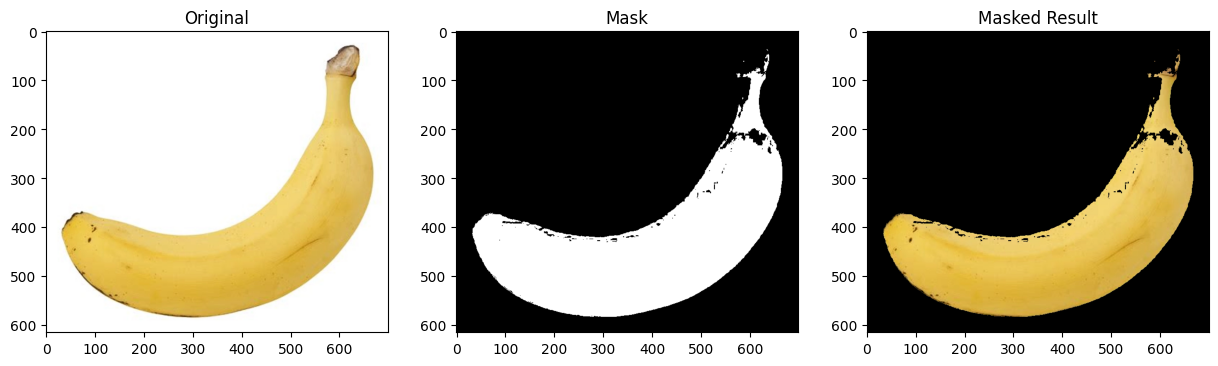

In [89]:
img_banana = cv.imread('Images/banana.png')
img_banana_hsv = cv.cvtColor(img_banana, cv.COLOR_BGR2HSV)
img_banana_rgb = cv.cvtColor(img_banana, cv.COLOR_BGR2RGB)

lower_banana = np.array([14, 130, 90])
upper_banana = np.array([31, 255, 255])

mask_banana = cv.inRange(img_banana_hsv, lower_banana, upper_banana)
result_banana = cv.bitwise_and(img_banana_rgb, img_banana_rgb, mask=mask_banana)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_banana_rgb); axes[0].set_title('Original')
axes[1].imshow(mask_banana, cmap='gray'); axes[1].set_title('Mask')
axes[2].imshow(result_banana); axes[2].set_title('Masked Result')
plt.show()

In [95]:
img_lime = cv.imread('Images/lime.png')
img_lime_hsv = cv.cvtColor(img_lime, cv.COLOR_BGR2HSV)
img_lime_rgb = cv.cvtColor(img_lime, cv.COLOR_BGR2RGB)


print(img_lime_hsv[200, 300])   
print(img_lime_hsv[150, 250])   
print(img_lime_hsv[220, 350])   
print(img_lime_hsv[110, 300])   

[ 34 104 225]
[ 36 157 233]
[ 36 169 216]
[  0   0 254]


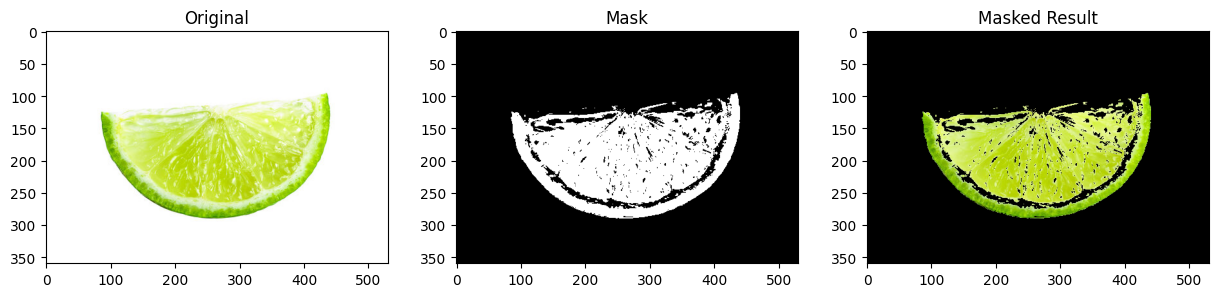

In [96]:

lower_lime = np.array([24, 80, 90])
upper_lime = np.array([46, 255, 255])

mask_lime = cv.inRange(img_lime_hsv, lower_lime, upper_lime)
result_lime = cv.bitwise_and(img_lime_rgb, img_lime_rgb, mask=mask_lime)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_lime_rgb); axes[0].set_title('Original')
axes[1].imshow(mask_lime, cmap='gray'); axes[1].set_title('Mask')
axes[2].imshow(result_lime); axes[2].set_title('Masked Result')
plt.show()

### Fruit HSV Color Ranges 

| Fruit | H_min | H_max | S_min | S_max | V_min | V_max |
|---|---|---|---|---|---|---|
| Green Apple | 25 | 45 | 90 | 255 | 80 | 255 |
| Banana | 14 | 31 | 130 | 255 | 90 | 255 |
| Lime | 24 | 46 | 80 | 255 | 90 | 255 |

### 5.Apply manual brightness/contrast to a dark banana image(alpha=1.3, beta=20) using NumPy. Clip to [0,255] and convert to uint8. Compareto cv2.convertScaleAbs(). Does it make the HSV mask more reliable?

`new pixel = alpha x old_pixel + beta`
- alpha (contrast/gain) :multiplies every pixel value. alpha > 1 stretches the spread between dark and light pixels apart (more contrast). alpha=1.3 means every pixel gets 30% "stronger."

- beta (brightness/offset) :adds a flat amount to every pixel. beta=20 just shifts the whole image 20 units brighter, uniformly.

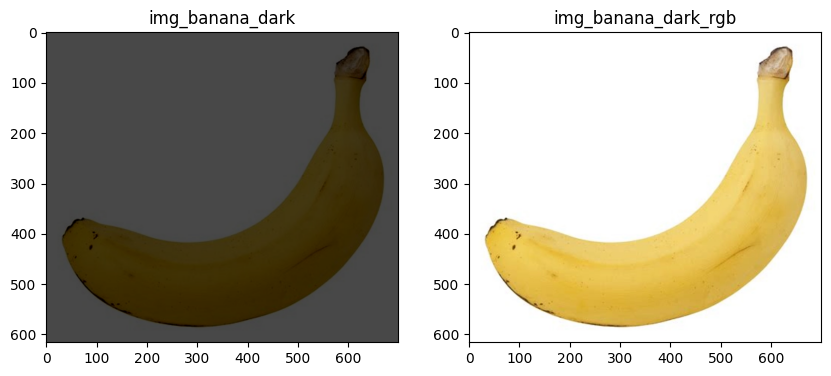

In [109]:
img_banana = cv.imread('Images/banana.png')
img_banana_rgb = cv.cvtColor(img_banana, cv.COLOR_BGR2RGB)

# darken it artificially
img_banana_dark = np.clip(img_banana_rgb.astype(np.float32) * 0.4 - 30, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1,2,figsize=(10,5))
axes[0].imshow(img_banana_dark)
axes[0].set_title('img_banana_dark')
axes[1].imshow(img_banana_rgb)
plt.title('img_banana_dark_rgb')
plt.show()

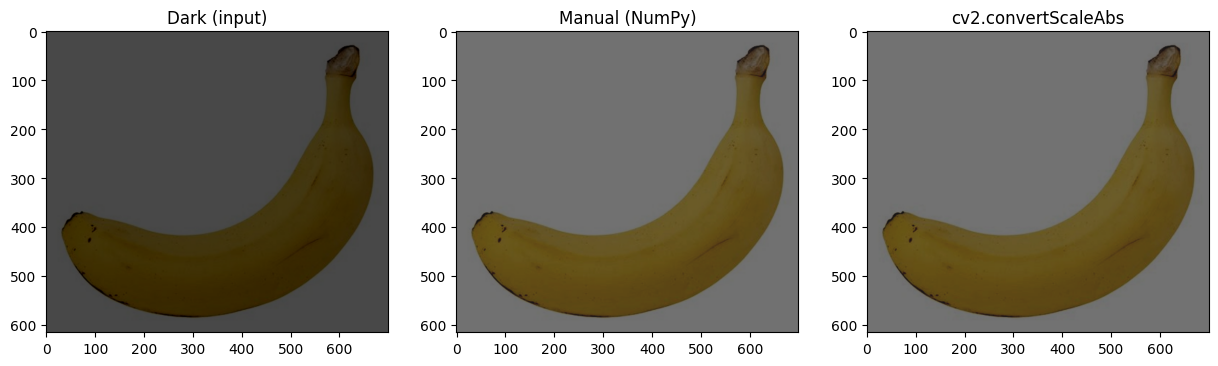

Max pixel difference: 1
Are they identical?: False


In [ ]:
alpha = 1.3
beta = 20

# Manual method
manual = img_banana_dark.astype(np.float32) * alpha + beta
manual_clipped = np.clip(manual, 0, 255).astype(np.uint8)

opencv_version = cv.convertScaleAbs(img_banana_dark, alpha=alpha, beta=beta)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_banana_dark); axes[0].set_title('Dark (input)')
axes[1].imshow(manual_clipped); axes[1].set_title('Manual (NumPy)')
axes[2].imshow(opencv_version); axes[2].set_title('cv2.convertScaleAbs')
plt.show()

# Are they actually identical?
diff = cv.absdiff(manual_clipped, opencv_version)
print("Max pixel difference:", diff.max())
print("Are they identical?:", np.array_equal(manual_clipped, opencv_version))

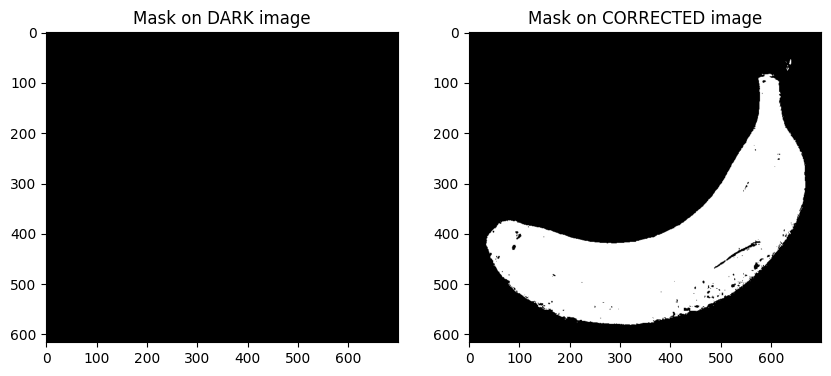

In [112]:
# HSV mask on the DARK banana (before correction)
dark_hsv = cv.cvtColor(img_banana_dark, cv.COLOR_RGB2HSV)
mask_dark = cv.inRange(dark_hsv, lower_banana, upper_banana)

# HSV mask on the CORRECTED banana (after alpha/beta fix)
corrected_hsv = cv.cvtColor(manual_clipped, cv.COLOR_RGB2HSV)
mask_corrected = cv.inRange(corrected_hsv, lower_banana, upper_banana)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(mask_dark, cmap='gray')
axes[0].set_title('Mask on DARK image')
axes[1].imshow(mask_corrected, cmap='gray')
axes[1].set_title('Mask on CORRECTED image')
plt.show()

#### Does it make the HSV mask more reliable?
Yes, decisively. The dark image is 0% detected (mask completely fails), while brightness/contrast correction restores it to a fully working, near-original-quality mask. Correction doesn't just "help a little" — it's the difference between total failure and success here.

### 6.  Reflection: why does HSV work better than RGB for fruit color segmentation? When would it fail? (Hint: try a very dark purple grape or blueberry.)

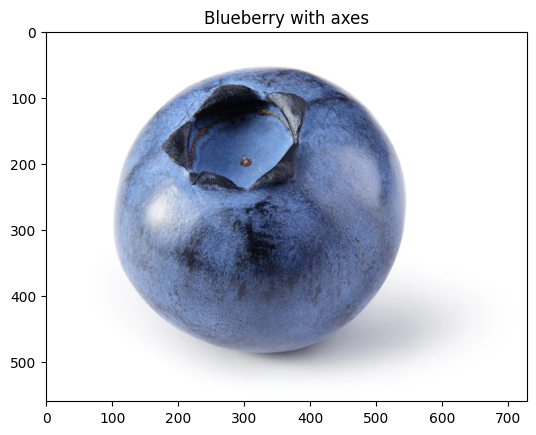

In [113]:
img_blueberry = cv.imread('Images/blueberry.png')   # adjust filename/extension to match your file
img_blueberry_hsv = cv.cvtColor(img_blueberry, cv.COLOR_BGR2HSV)
img_blueberry_rgb = cv.cvtColor(img_blueberry, cv.COLOR_BGR2RGB)

plt.imshow(img_blueberry_rgb)
plt.title('Blueberry with axes')
plt.show()

In [114]:
print("Highlight:", img_blueberry_hsv[180, 180])
print("Mid-tone", img_blueberry_hsv[280, 350])
print("Shadow:", img_blueberry_hsv[350, 450])
print("Near-black:", img_blueberry_hsv[150, 300])

Highlight: [125  46 112]
Mid-tone [112 115 146]
Shadow: [110 106 166]
Near-black: [110 158 108]


HSV works better than RGB for fruit segmentation because it seprates color identity(Hue) from lighting(Value), So a red apple stays roughly the same hue whether it's in sun or shadow, while in RGB the same apple's numbers shifted entireely with brightness. IT failes in two cases 

1. when two fruits share a similar hue, like our lime(h 24-46) and green apple(H 25-45), which overlap alomost completly and ca't be separated by color alone 

2. at a very low brightness(dark purple grapes, blueberries), wher HUe itself becomes unstable and noisy, since it's mathematically derived from ratio between RGB that breaks down near black  

# Part B — Histograms & Filtering

### 1. Load strawberry.jpg as grayscale. Plot its histogram. Is the image well-exposed? What does the histogram shape tell you about contrast?

In [5]:
# this collapses the 3 color channels into 1 brightness channedl 
# using weighted averages of RGB 
img_strawberry_gray= cv.imread("Images/strawberry.png", cv.IMREAD_GRAYSCALE)

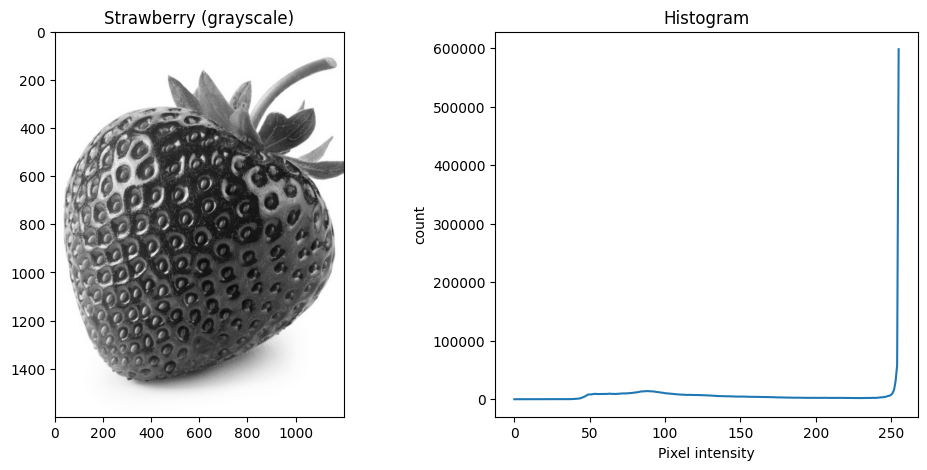

In [8]:
hist = cv.calcHist([img_strawberry_gray], [0], None, [256], [0, 256])

fig, axes = plt.subplots(1, 2, figsize = (12,5))
axes[0].imshow(img_strawberry_gray, cmap='gray')
axes[0].set_title("Strawberry (grayscale)")
axes[1].plot(hist)
axes[1].set_title("Histogram")
axes[1].set_xlabel("Pixel intensity")
axes[1].set_ylabel("count")
plt.show()


That giant Spike at 255 is almost certainly the white background contributes a huge flat block of identical bright pixels,the small bump around 50-100 is the actual strawberry itself, it seeds, ,shadows and red pat 

### 2.Apply global histogram equalization (cv2.equalizeHist()). Then apply CLAHE with clipLimit=2.0 and clipLimit=8.0. Show all four versions side by side (original, equalized, CLAHE-2, CLAHE-8). Which helps the HSV segmentation mask most?

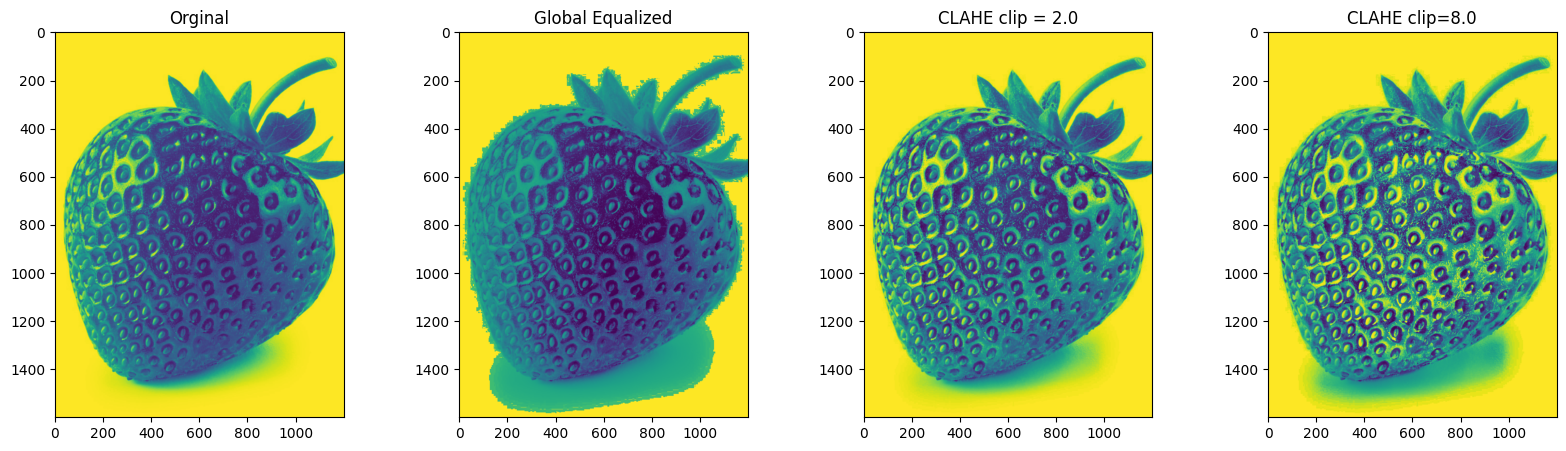

In [ ]:
eq = cv.equalizeHist(img_strawberry_gray)

# CHALE clipLimit = 2.0
clahe2 = cv.createCLAHE(clipLimit=2.0, tileGridSize= (8,8))
clahe2_img = clahe2.apply(img_strawberry_gray)

# CHALE clipLimit = 8.0
clahe8 = cv.createCLAHE(clipLimit=8.0, tileGridSize = (8,8))
clahe8_img = clahe8.apply(img_strawberry_gray)

fig, axes = plt.subplots(1, 4, figsize = (20,5))
axes[0].imshow(img_strawberry_gray)
axes[0].set_title("Orginal")
axes[1].imshow(eq)
axes[1].set_title("Global Equalized")
axes[2].imshow(clahe2_img)
axes[2].set_title('CLAHE clip = 2.0')
axes[3].imshow(clahe8_img)
axes[3].set_title('CLAHE clip=8.0')
plt.show()

In [13]:
# Which helps the HSV segmentation mask most?
# CLAHE with clipLimit=2.0 helps the HSV segmentation mask most

### 3.Noise experiment: add Gaussian noise (mean=0, std=25) to orange.jpg using np.random.normal(). Apply Gaussian blur, median filter, and bilateral filter. Which removes the noise best while keeping the fruit’s edge sharp? Plot all four for comparison.